# CodoMax AI/ML Internship
## Module 4 — Machine Learning Fundamentals

**Level:** High  
**Duration:** Day 13 – Day 16

### Objective

In this module, I will learn the basic Machine Learning workflow by building a classification model using the Iris dataset and Scikit-learn.

### Machine Learning Workflow

1. Load the dataset
2. Explore the data
3. Prepare features and target
4. Split the data into training and testing sets
5. Train a Machine Learning model
6. Make predictions
7. Evaluate model performance
8. Analyze the results

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)


Numpy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1


In [42]:
from sklearn.datasets import load_iris
iris = load_iris()

print("Dataset loaded successfully!")
print("Features:", iris.feature_names)
print("Target Classes:", iris.target_names)

Dataset loaded successfully!
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa' 'versicolor' 'virginica']


In [43]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))

)

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [44]:
# Check dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


In [45]:
# Check column names
print("Columns:")
print(df.columns.tolist())

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']


In [46]:
# Check data types and non-null values
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [47]:
# Statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [48]:
# Check target class distribution
print("Class Distribution:")
print(df["species"].value_counts())

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [49]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [50]:
# Define features (X) and target (y)

X = df[iris.feature_names]
y = df["target"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y):


,target
0,0
1,0
2,0
3,0
4,0


In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [52]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training targets: (120,)
Testing targets: (30,)


In [53]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
model = KNeighborsClassifier(n_neighbors=3)

print("KNN model created successfully!")

KNN model created successfully!


In [55]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [56]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison)

In [57]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


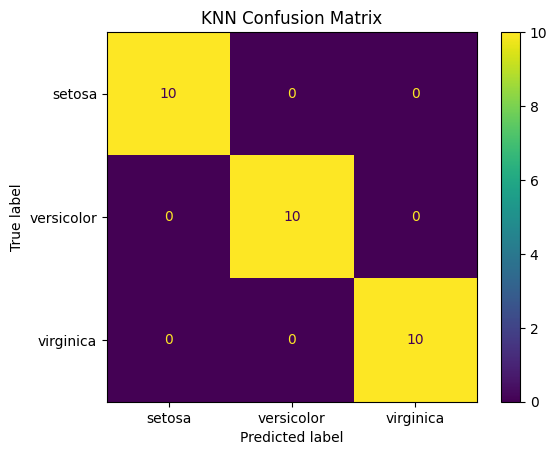

In [59]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



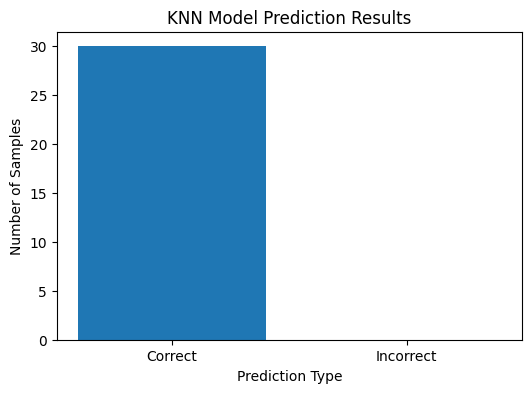

In [61]:
# Count correct and incorrect predictions
correct = (y_test == y_pred).sum()
incorrect = (y_test != y_pred).sum()

labels = ["Correct", "Incorrect"]
values = [correct, incorrect]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)

plt.title("KNN Model Prediction Results")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Samples")

plt.show()

## Conclusion

In this module, I built a Machine Learning classification model using the Iris dataset and Scikit-learn.

The dataset was divided into training and testing sets. A K-Nearest Neighbors (KNN) classifier was trained using the training data and evaluated on unseen testing data.

The model achieved a high accuracy on the test dataset, demonstrating that it was able to classify Iris flower species effectively based on their measurements.

### Key Learnings

- Understanding the basic Machine Learning workflow
- Preparing features and target variables
- Splitting data into training and testing sets
- Training a KNN classification model
- Making predictions
- Evaluating model accuracy
- Using a confusion matrix and classification report
- Visualizing model prediction results